In [ ]:
# Install required libraries
!pip install earthengine-api
!pip install tensorflow==2.12.0
!pip install numpy pandas scikit-learn opencv-python matplotlib

# Import libraries
import ee
import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import matplotlib.pyplot as plt

# Set working directory in local Colab storage
os.makedirs('/content/land_cover_project', exist_ok=True)
os.chdir('/content/land_cover_project')

# Authenticate Google Earth Engine
try:
    ee.Initialize(project='vijayawada-landcover-456705')
except Exception:
    ee.Authenticate()  # This will prompt for authentication
    ee.Initialize()

print("Google Earth Engine authenticated and initialized successfully!")

Google Earth Engine authenticated and initialized successfully!


In [ ]:
import ee
import os
import numpy as np
from datetime import datetime

# Ensure working directory is set
os.makedirs('/content/land_cover_project/data', exist_ok=True)

# Define Vijayawada's Region of Interest (ROI) using approximate bounding box coordinates
vijayawada_roi = ee.Geometry.Rectangle([80.55, 16.45, 80.75, 16.65])  # [minLon, minLat, maxLon, maxLat]

# Define time periods
start_date_2010 = '2010-01-01'
end_date_2010 = '2010-12-31'
start_date_2020 = '2020-01-01'
end_date_2020 = '2020-12-31'

# Function to mask clouds in Landsat imagery
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 5).eq(0))
    return image.updateMask(cloud_mask)

# Load Landsat collections (Landsat 5 for 2010, Landsat 8 for 2020)
landsat_2010 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
                .filterBounds(vijayawada_roi)
                .filterDate(start_date_2010, end_date_2010)
                .map(mask_clouds)
                .median())  # Use median to reduce noise

landsat_2020 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
                .filterBounds(vijayawada_roi)
                .filterDate(start_date_2020, end_date_2020)
                .map(mask_clouds)
                .median())

# Select relevant bands (similar to paper: Blue, Green, Red, NIR, SWIR1, SWIR2)
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']  # Adjusted for Landsat naming
landsat_2010 = landsat_2010.select(bands)
landsat_2020 = landsat_2020.select(bands)

# Define land cover classes for Vijayawada (at least 8)
land_cover_classes = [
    'Urban', 'Agricultural Land', 'Forest', 'Water Bodies',
    'Barren Land', 'Grassland', 'Wetlands', 'Plantations'
]

# Export images to local Colab storage as GeoTIFF
task_2010 = ee.batch.Export.image.toAsset(
    image=landsat_2010,
    description='Landsat_2010_Vijayawada',
    assetId='users/gudivadaswathi2/landsat_2010_vijayawada',  # Replace with your GEE username
    region=vijayawada_roi,
    scale=30,  # 30m resolution
    maxPixels=1e9
)

task_2020 = ee.batch.Export.image.toAsset(
    image=landsat_2020,
    description='Landsat_2020_Vijayawada',
    assetId='users/gudivadaswathi2/landsat_2020_vijayawada',  # Replace with your GEE username
    region=vijayawada_roi,
    scale=30,
    maxPixels=1e9
)

# Start export tasks
task_2010.start()
task_2020.start()

print("Export tasks started. Check GEE console for status. Images will be saved as assets.")

# To download to local storage, we'll convert assets to GeoTIFF later

Export tasks started. Check GEE console for status. Images will be saved as assets.


In [ ]:
import os
import numpy as np
import rasterio
import cv2
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Paths to preprocessed images
data_dir = '/content/land_cover_project/data'
preprocessed_2010 = os.path.join(data_dir, 'preprocessed_2010.tiff')
preprocessed_2020 = os.path.join(data_dir, 'preprocessed_2020.tiff')
feature_dir = os.path.join(data_dir, 'features')
os.makedirs(feature_dir, exist_ok=True)

# Enhanced preprocessing function with CRS reprojection and noise removal
def enhanced_preprocess_image(input_path, output_path):
    with rasterio.open(input_path) as src:
        img = src.read()  # Shape: (bands, height, width)
        src_profile = src.profile
        src_crs = src.crs

    # Reproject to UTM Zone 44N (EPSG:32644) if not already
    dst_crs = 'EPSG:32644'
    if src_crs != dst_crs:
        transform, width, height = calculate_default_transform(
            src_crs, dst_crs, src.width, src.height, *src.bounds
        )
        dst_profile = src_profile.copy()
        dst_profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        img_reprojected = np.zeros((img.shape[0], height, width), dtype=np.float32)
        for i in range(img.shape[0]):
            reproject(
                source=img[i],
                destination=img_reprojected[i],
                src_transform=src.transform,
                src_crs=src_crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear
            )
        img = img_reprojected
        profile = dst_profile
        print(f"Reprojected {input_path} to EPSG:32644")
    else:
        profile = src_profile
        print(f"{input_path} already in EPSG:32644")

    # Radiometric consistency: Scale Level-2 reflectance (0-10000 to 0-1)
    img = img.astype(np.float32)
    img = np.clip(img / 10000.0, 0, 1)

    # Noise removal: Gaussian blur
    img = np.transpose(img, (1, 2, 0))  # To (height, width, bands)
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    img_clean = img_blur.astype(np.float32)

    # Save enhanced preprocessed image
    profile.update(dtype=rasterio.float32)
    with rasterio.open(output_path, 'w', **profile) as dst:
        img_clean = np.transpose(img_clean, (2, 0, 1))  # Back to (bands, height, width)
        dst.write(img_clean)

    print(f"Enhanced preprocessed image saved to {output_path}")
    return img_clean, profile

# Function to compute vegetation indices
def compute_vegetation_indices(img, profile, year):
    # Band order: B1 (Blue), B2 (Green), B3 (Red), B4 (NIR), B5 (SWIR1), B7 (SWIR2)
    blue, green, red, nir, swir1, swir2 = img[:, :, 0], img[:, :, 1], img[:, :, 2], img[:, :, 3], img[:, :, 4], img[:, :, 5]

    # Helper function to avoid division by zero
    def safe_divide(a, b):
        return np.divide(a, b, out=np.zeros_like(a, dtype=np.float32), where=b!=0)

    # 1. NDVI
    ndvi = safe_divide(nir - red, nir + red)
    with rasterio.open(os.path.join(feature_dir, f'ndvi_{year}.tiff'), 'w', **profile) as dst:
        dst.write(ndvi, 1)

    # 2. SAVI (L=0.5)
    L = 0.5
    savi = safe_divide(nir - red, nir + red + L) * (1 + L)
    with rasterio.open(os.path.join(feature_dir, f'savi_{year}.tiff'), 'w', **profile) as dst:
        dst.write(savi, 1)

    # 3. WVI (simplified weights)
    wvi = (0.1 * blue + 0.2 * green + 0.3 * red + 0.4 * nir) / (0.1 + 0.2 + 0.3 + 0.4)
    with rasterio.open(os.path.join(feature_dir, f'wvi_{year}.tiff'), 'w', **profile) as dst:
        dst.write(wvi, 1)

    # 4. GEMI
    eta = (2 * (nir**2 - red**2) + 1.5 * nir + 0.5 * red) / (nir + red + 0.5)
    gemi = eta * (1 - 0.25 * eta) - safe_divide(red - 0.125, 1 - red)
    with rasterio.open(os.path.join(feature_dir, f'gemi_{year}.tiff'), 'w', **profile) as dst:
        dst.write(gemi, 1)

    # 5. MSAVI
    msavi = (2 * nir + 1 - np.sqrt((2 * nir + 1)**2 - 8 * (nir - red))) / 2
    with rasterio.open(os.path.join(feature_dir, f'msavi_{year}.tiff'), 'w', **profile) as dst:
        dst.write(msavi, 1)

    # 6. MSR
    msr = safe_divide(nir - red, nir + red + 0.5)
    with rasterio.open(os.path.join(feature_dir, f'msr_{year}.tiff'), 'w', **profile) as dst:
        dst.write(msr, 1)

    print(f"Vegetation indices for {year} saved in {feature_dir}")
    return [ndvi, savi, wvi, gemi, msavi, msr]

# Process both images
img_2010, profile_2010 = enhanced_preprocess_image(preprocessed_2010, os.path.join(data_dir, 'enhanced_2010.tiff'))
img_2020, profile_2020 = enhanced_preprocess_image(preprocessed_2020, os.path.join(data_dir, 'enhanced_2020.tiff'))

# Compute vegetation indices
indices_2010 = compute_vegetation_indices(img_2010, profile_2010, '2010')
indices_2020 = compute_vegetation_indices(img_2020, profile_2020, '2020')

# Verify feature files
print("Feature files generated:")
print(os.listdir(feature_dir))

Reprojected /content/land_cover_project/data/preprocessed_2010.tiff to EPSG:32644
Enhanced preprocessed image saved to /content/land_cover_project/data/enhanced_2010.tiff
Reprojected /content/land_cover_project/data/preprocessed_2020.tiff to EPSG:32644
Enhanced preprocessed image saved to /content/land_cover_project/data/enhanced_2020.tiff
Vegetation indices for 2010 saved in /content/land_cover_project/data/features
Vegetation indices for 2020 saved in /content/land_cover_project/data/features
Feature files generated:
['savi_2020.tiff', 'savi_2010.tiff', 'ndvi_2020.tiff', 'msr_2020.tiff', 'wvi_2020.tiff', 'wvi_2010.tiff', 'msavi_2020.tiff', 'msavi_2010.tiff', 'msr_2010.tiff', 'gemi_2020.tiff', 'gemi_2010.tiff', 'ndvi_2010.tiff']


Stats for 2010:
NDVI - Min: -0.024, Max: 0.164, Mean: 0.037
NIR - Min: 0.002, Max: 0.022, Mean: 0.016
Red - Min: 0.001, Max: 0.018, Mean: 0.012
Blue - Min: 0.001, Max: 0.014, Mean: 0.010
Stats for 2020:
NDVI - Min: -0.031, Max: 0.170, Mean: 0.037
NIR - Min: 0.001, Max: 0.018, Mean: 0.010
Red - Min: 0.001, Max: 0.015, Mean: 0.010
Blue - Min: 0.001, Max: 0.012, Mean: 0.009
Class distribution: {'Urban': 241044, 'Agricultural Land': 9210, 'Forest': 53704, 'Water Bodies': 9, 'Barren Land': 234340, 'Grassland': 15791}
Class distribution: {'Urban': 312027, 'Agricultural Land': 7200, 'Forest': 55714, 'Water Bodies': 241, 'Barren Land': 167193, 'Grassland': 11723}


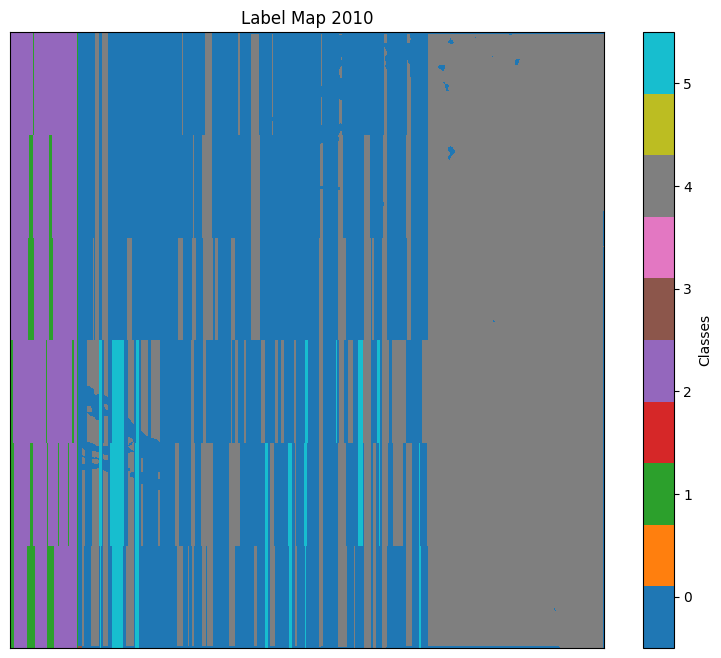

Training data prepared and saved:
X_train shape: (886556, 1, 12)
X_val shape: (221640, 1, 12)
y_train shape: (886556,)
y_val shape: (221640,)
Classes: [0 1 2 3 4 5]


In [ ]:
import os
import numpy as np
import rasterio
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Paths
data_dir = '/content/land_cover_project/data'
feature_dir = os.path.join(data_dir, 'features')
enhanced_2010 = os.path.join(data_dir, 'enhanced_2010.tiff')
enhanced_2020 = os.path.join(data_dir, 'enhanced_2020.tiff')

# Land cover classes (removed Wetlands and Plantations)
land_cover_classes = ['Urban', 'Agricultural Land', 'Forest', 'Water Bodies', 'Barren Land', 'Grassland']

# Load feature maps and imagery
def load_features(year):
    indices = ['ndvi', 'savi', 'wvi', 'gemi', 'msavi', 'msr']
    feature_stack = []
    for idx in indices:
        with rasterio.open(os.path.join(feature_dir, f'{idx}_{year}.tiff')) as src:
            feature_stack.append(src.read(1))

    with rasterio.open(os.path.join(data_dir, f'enhanced_{year}.tiff')) as src:
        img = src.read()
        for i in range(img.shape[0]):
            feature_stack.append(img[i])

    feature_stack = np.stack(feature_stack, axis=-1)  # Shape: (height, width, 12)
    return feature_stack

# Load data
features_2010 = load_features('2010')
features_2020 = load_features('2020')

# Debug: Print feature statistics
def print_feature_stats(features, year):
    ndvi = features[:, :, 0]
    nir = features[:, :, 9]
    red = features[:, :, 8]
    blue = features[:, :, 6]
    print(f"Stats for {year}:")
    print(f"NDVI - Min: {np.nanmin(ndvi):.3f}, Max: {np.nanmax(ndvi):.3f}, Mean: {np.nanmean(ndvi):.3f}")
    print(f"NIR - Min: {np.nanmin(nir):.3f}, Max: {np.nanmax(nir):.3f}, Mean: {np.nanmean(nir):.3f}")
    print(f"Red - Min: {np.nanmin(red):.3f}, Max: {np.nanmax(red):.3f}, Mean: {np.nanmean(red):.3f}")
    print(f"Blue - Min: {np.nanmin(blue):.3f}, Max: {np.nanmax(blue):.3f}, Mean: {np.nanmean(blue):.3f}")

print_feature_stats(features_2010, '2010')
print_feature_stats(features_2020, '2020')

# Updated labeling function for 6 classes
def simulate_labels(features, height, width):
    labels = np.zeros((height, width), dtype=np.int32)
    ndvi = features[:, :, 0]
    nir = features[:, :, 9]
    red = features[:, :, 8]
    blue = features[:, :, 6]

    for i in range(height):
        for j in range(width):
            if ndvi[i, j] > 0.15:  # Forest (near max NDVI ~0.17)
                labels[i, j] = 2
            elif 0.10 <= ndvi[i, j] <= 0.15:  # Agricultural Land
                labels[i, j] = 1
            elif 0.05 <= ndvi[i, j] < 0.10:  # Grassland
                labels[i, j] = 5
            elif ndvi[i, j] < 0.03 and red[i, j] > 0.01:  # Barren Land (tighter NDVI)
                labels[i, j] = 4
            elif blue[i, j] < 0.006 and nir[i, j] < 0.006 and red[i, j] < 0.006:  # Water Bodies (slightly relaxed)
                labels[i, j] = 3
            else:
                labels[i, j] = 0  # Urban

    # Class distribution
    unique, counts = np.unique(labels, return_counts=True)
    class_dict = {land_cover_classes[i]: 0 for i in range(len(land_cover_classes))}
    for u, c in zip(unique, counts):
        class_dict[land_cover_classes[u]] = c
    print("Class distribution:", class_dict)

    return labels

# Get dimensions
height, width, _ = features_2010.shape
labels_2010 = simulate_labels(features_2010, height, width)
labels_2020 = simulate_labels(features_2020, height, width)

# Visualize labels for 2010
plt.figure(figsize=(10, 8))
plt.imshow(labels_2010, cmap='tab10', interpolation='nearest')
plt.colorbar(ticks=range(len(land_cover_classes)), label='Classes')
plt.clim(-0.5, len(land_cover_classes)-0.5)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.title('Label Map 2010')
plt.show()

# Save labels as GeoTIFF
def save_labels(labels, profile, output_path):
    profile.update(dtype=rasterio.int32, count=1)
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(labels, 1)

with rasterio.open(enhanced_2010) as src:
    profile = src.profile
save_labels(labels_2010, profile, os.path.join(data_dir, 'labels_2010.tiff'))
save_labels(labels_2020, profile, os.path.join(data_dir, 'labels_2020.tiff'))

# Flatten data
X_2010 = features_2010.reshape(-1, 12)
y_2010 = labels_2010.reshape(-1)
X_2020 = features_2020.reshape(-1, 12)
y_2020 = labels_2020.reshape(-1)

# Combine data
X = np.vstack([X_2010, X_2020])
y = np.hstack([y_2010, y_2020])

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Reshape for BiLSTM
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

# Save data
np.save(os.path.join(data_dir, 'X_train.npy'), X_train)
np.save(os.path.join(data_dir, 'X_val.npy'), X_val)
np.save(os.path.join(data_dir, 'y_train.npy'), y_train)
np.save(os.path.join(data_dir, 'y_val.npy'), y_val)
np.save(os.path.join(data_dir, 'label_encoder_classes.npy'), encoder.classes_)

print("Training data prepared and saved:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"Classes: {encoder.classes_}")

Epoch 1/10
27705/27705 [==============================] - 173s 6ms/step - loss: 0.2356 - accuracy: 0.9063 - val_loss: 0.1131 - val_accuracy: 0.9520
Epoch 2/10
27705/27705 [==============================] - 160s 6ms/step - loss: 0.1463 - accuracy: 0.9384 - val_loss: 0.1037 - val_accuracy: 0.9542
Epoch 3/10
27705/27705 [==============================] - 151s 5ms/step - loss: 0.1358 - accuracy: 0.9430 - val_loss: 0.1106 - val_accuracy: 0.9551
Epoch 4/10
27705/27705 [==============================] - 155s 6ms/step - loss: 0.1299 - accuracy: 0.9450 - val_loss: 0.0800 - val_accuracy: 0.9699
Epoch 5/10
27705/27705 [==============================] - 155s 6ms/step - loss: 0.1242 - accuracy: 0.9473 - val_loss: 0.0826 - val_accuracy: 0.9646
Epoch 6/10
27705/27705 [==============================] - 154s 6ms/step - loss: 0.1186 - accuracy: 0.9498 - val_loss: 0.1016 - val_accuracy: 0.9553
Epoch 7/10
27705/27705 [==============================] - 157s 6ms/step - loss: 0.1121 - accuracy: 0.9524 - val_

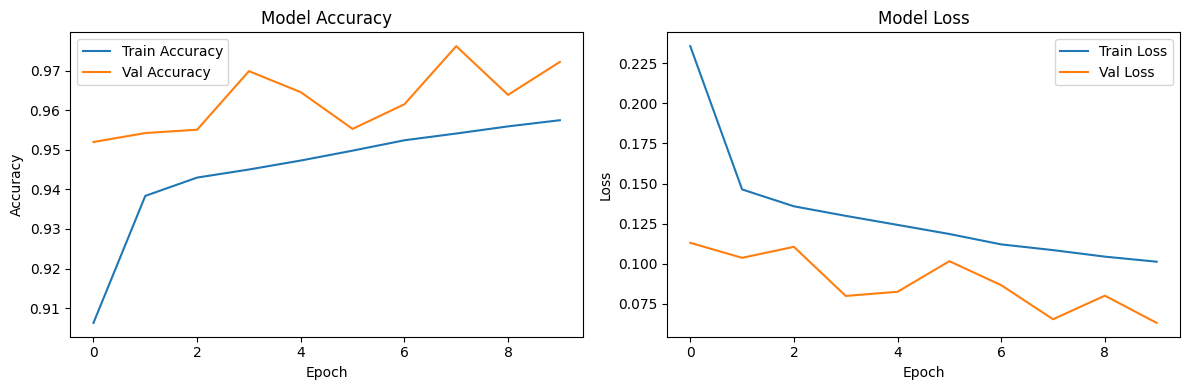

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Paths
data_dir = '/content/land_cover_project/data'

# Load training data
X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
X_val = np.load(os.path.join(data_dir, 'X_val.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
y_val = np.load(os.path.join(data_dir, 'y_val.npy'))
classes = np.load(os.path.join(data_dir, 'label_encoder_classes.npy'), allow_pickle=True)

# Define FHO-BiLSTM model
def build_fho_bilstm(num_classes):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=False), input_shape=(1, 12)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Custom FHO optimizer (FSA + SHO hybrid)
class FHOAdam(Adam):
    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, **kwargs):
        super().__init__(learning_rate, beta_1, beta_2, epsilon, **kwargs)
        self.best_weights = None  # Track best solution (SHO-inspired)
        self.best_loss = float('inf')

    def _resource_apply_dense(self, grad, var, apply_state=None):
        # Standard Adam update
        lr = self._get_hyper('learning_rate')
        update = super()._resource_apply_dense(grad, var, apply_state)

        # FSA-inspired: Random perturbation (foraging exploration)
        if np.random.random() < 0.15:  # 15% chance, like flamingo foraging
            perturbation = np.random.uniform(-0.1 * lr, 0.1 * lr)
            var.assign_add(perturbation * var)

        # SHO-inspired: Move toward best solution (encircling prey)
        if self.best_weights is not None and np.random.random() < 0.1:  # 10% chance
            # Simulate hyena moving toward prey (best weights)
            direction = self.best_weights - var
            var.assign_add(0.05 * direction)  # Small step toward best

        return update

    def _update_best(self, model, loss):
        # Update best weights if current loss is lower (SHO tracking)
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_weights = [w.numpy().copy() for w in model.trainable_weights]

# Build model
num_classes = len(np.unique(y_train))  # Should be 6
model = build_fho_bilstm(num_classes)

# Compile model
optimizer = FHOAdam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: optimizer._update_best(
                model, logs.get('val_loss')
            )
        )
    ]
)

# Save model
model.save(os.path.join(data_dir, 'fho_bilstm_model.h5'))

# Evaluate model
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrics
accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes, average='weighted', zero_division=0)
recall = recall_score(y_val, y_pred_classes, average='weighted', zero_division=0)
f1 = f1_score(y_val, y_pred_classes, average='weighted', zero_division=0)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

17316/17316 [==============================] - 34s 2ms/step
Change Detection (significant transitions):
Urban -> Barren Land: 27682 pixels
Urban -> Grassland: 3743 pixels
Agricultural Land -> Forest: 4754 pixels
Forest -> Agricultural Land: 2850 pixels
Water Bodies -> Urban: 1 pixels
Barren Land -> Urban: 84803 pixels
Barren Land -> Grassland: 127 pixels
Grassland -> Urban: 8168 pixels
Grassland -> Barren Land: 252 pixels


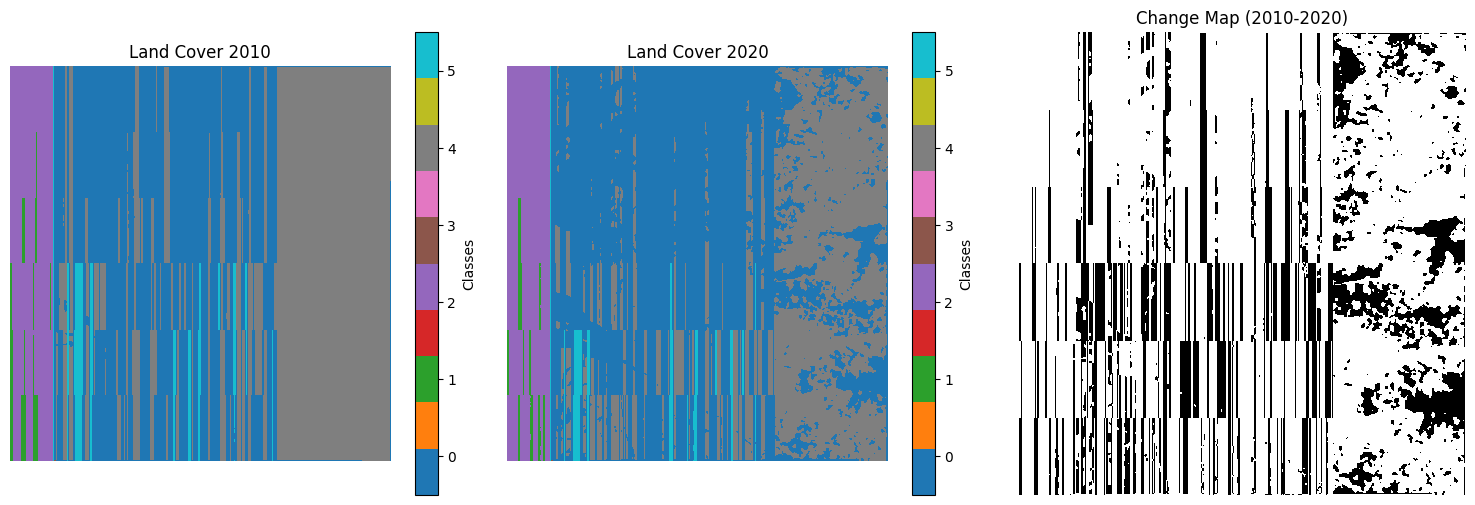

In [ ]:
import os
import numpy as np
import rasterio
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Paths
data_dir = '/content/land_cover_project/data'
feature_dir = os.path.join(data_dir, 'features')
enhanced_2010 = os.path.join(data_dir, 'enhanced_2010.tiff')
enhanced_2020 = os.path.join(data_dir, 'enhanced_2020.tiff')

# Land cover classes
land_cover_classes = ['Urban', 'Agricultural Land', 'Forest', 'Water Bodies', 'Barren Land', 'Grassland']

# Load feature maps and imagery
def load_features(year):
    indices = ['ndvi', 'savi', 'wvi', 'gemi', 'msavi', 'msr']
    feature_stack = []
    for idx in indices:
        with rasterio.open(os.path.join(feature_dir, f'{idx}_{year}.tiff')) as src:
            feature_stack.append(src.read(1))

    with rasterio.open(os.path.join(data_dir, f'enhanced_{year}.tiff')) as src:
        img = src.read()
        for i in range(img.shape[0]):
            feature_stack.append(img[i])

    feature_stack = np.stack(feature_stack, axis=-1)  # Shape: (height, width, 12)
    return feature_stack

# Custom FHO optimizer (FSA + SHO hybrid) - needed for loading the model
class FHOAdam(tf.keras.optimizers.Adam):
    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, **kwargs):
        super().__init__(learning_rate, beta_1, beta_2, epsilon, **kwargs)
        self.best_weights = None
        self.best_loss = float('inf')

    def _resource_apply_dense(self, grad, var, apply_state=None):
        lr = self._get_hyper('learning_rate')
        update = super()._resource_apply_dense(grad, var, apply_state)

        # FSA-inspired: Random perturbation
        if np.random.random() < 0.15:
            perturbation = np.random.uniform(-0.1 * lr, 0.1 * lr)
            var.assign_add(perturbation * var)

        # SHO-inspired: Move toward best solution
        if self.best_weights is not None and np.random.random() < 0.1:
            direction = self.best_weights - var
            var.assign_add(0.05 * direction)

        return update

    def _update_best(self, model, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_weights = [w.numpy().copy() for w in model.trainable_weights]

# Load data
features_2010 = load_features('2010')
features_2020 = load_features('2020')

# Load model with custom optimizer
model = tf.keras.models.load_model(
    os.path.join(data_dir, 'fho_bilstm_model.h5'),
    custom_objects={'FHOAdam': FHOAdam}
)
classes = np.load(os.path.join(data_dir, 'label_encoder_classes.npy'), allow_pickle=True)
encoder = LabelEncoder()
encoder.classes_ = classes

# Predict land cover
def predict_land_cover(features, model, height, width):
    X = features.reshape(-1, 12)  # (height * width, 12)
    X = X.reshape(X.shape[0], 1, X.shape[1])  # (samples, 1, 12)
    y_pred = model.predict(X, batch_size=32, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1)
    return y_pred_classes.reshape(height, width)  # (height, width)

# Get dimensions
height, width, _ = features_2010.shape

# Predict for both years
pred_2010 = predict_land_cover(features_2010, model, height, width)
pred_2020 = predict_land_cover(features_2020, model, height, width)

# Save predictions as GeoTIFF
def save_predictions(pred, profile, output_path):
    profile.update(dtype=rasterio.int32, count=1)
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(pred, 1)

with rasterio.open(enhanced_2010) as src:
    profile = src.profile
save_predictions(pred_2010, profile, os.path.join(data_dir, 'pred_2010.tiff'))
save_predictions(pred_2020, profile, os.path.join(data_dir, 'pred_2020.tiff'))

# Compute change detection
change_map = pred_2020 != pred_2010  # Pixels where class changed
change_counts = {}
for i in range(len(land_cover_classes)):
    for j in range(len(land_cover_classes)):
        count = np.sum((pred_2010 == i) & (pred_2020 == j))
        if count > 0 and i != j:
            change_counts[f"{land_cover_classes[i]} -> {land_cover_classes[j]}"] = count

print("Change Detection (significant transitions):")
for transition, count in change_counts.items():
    print(f"{transition}: {count} pixels")

# Visualize predictions and change map
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(pred_2010, cmap='tab10', interpolation='nearest')
plt.colorbar(ticks=range(len(land_cover_classes)), label='Classes')
plt.clim(-0.5, len(land_cover_classes)-0.5)
plt.title('Land Cover 2010')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(pred_2020, cmap='tab10', interpolation='nearest')
plt.colorbar(ticks=range(len(land_cover_classes)), label='Classes')
plt.clim(-0.5, len(land_cover_classes)-0.5)
plt.title('Land Cover 2020')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(change_map, cmap='binary', interpolation='nearest')
plt.title('Change Map (2010-2020)')
plt.axis('off')

plt.tight_layout()
plt.show()